In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


MONTE CARLO OPTION PRICER WITH GREEKS


  CALL OPTION:
    Monte Carlo Price  : $7.82
    Black-Scholes Price: $8.02
    Pricing Error      : 2.49%

  PUT OPTION:
    Monte Carlo Price  : $7.81
    Black-Scholes Price: $7.9
    Pricing Error      : 1.17%


OPTION GREEKS

CALL GREEKS:
Name:  BS:  MC:  Diff:
delta  0.54 0.39 0.15
gamma  0.02 -0.45 0.47
theta -0.02 -0.28 0.26
vega   0.4 0.41 0.01
rho    0.46 0.47 0.01

PUT GREEKS:
Name:  BS:  MC:  Diff:
delta  -0.46 -0.38 0.08
gamma  0.02 -0.23 0.25
theta -0.0 -0.02 0.02
vega   0.4 0.37 0.03
rho    -0.46 0.19 0.65


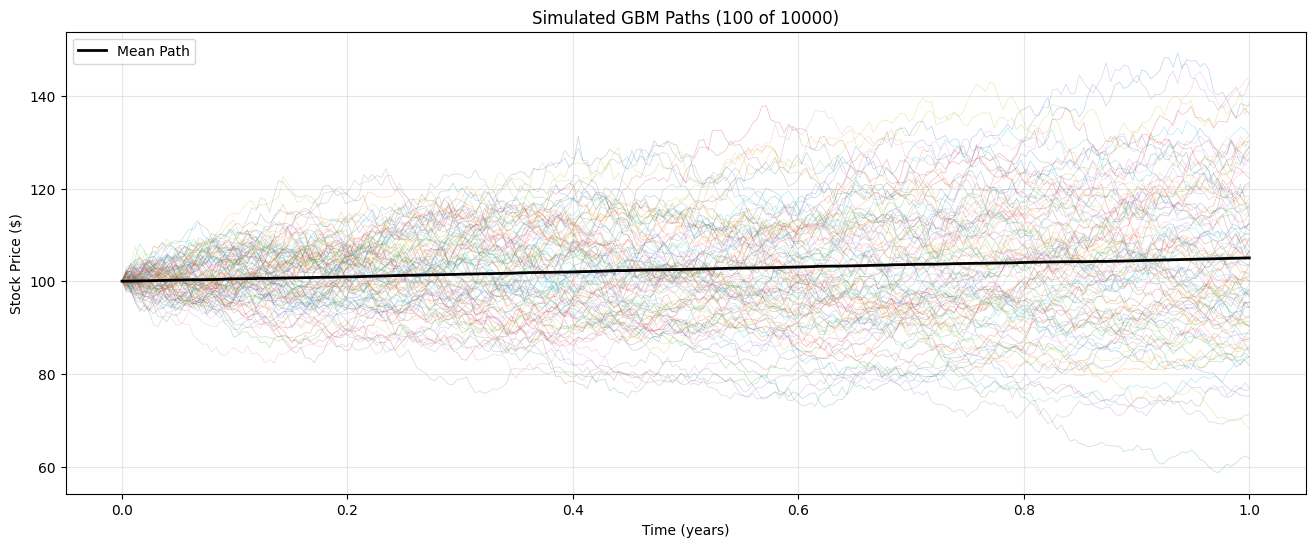

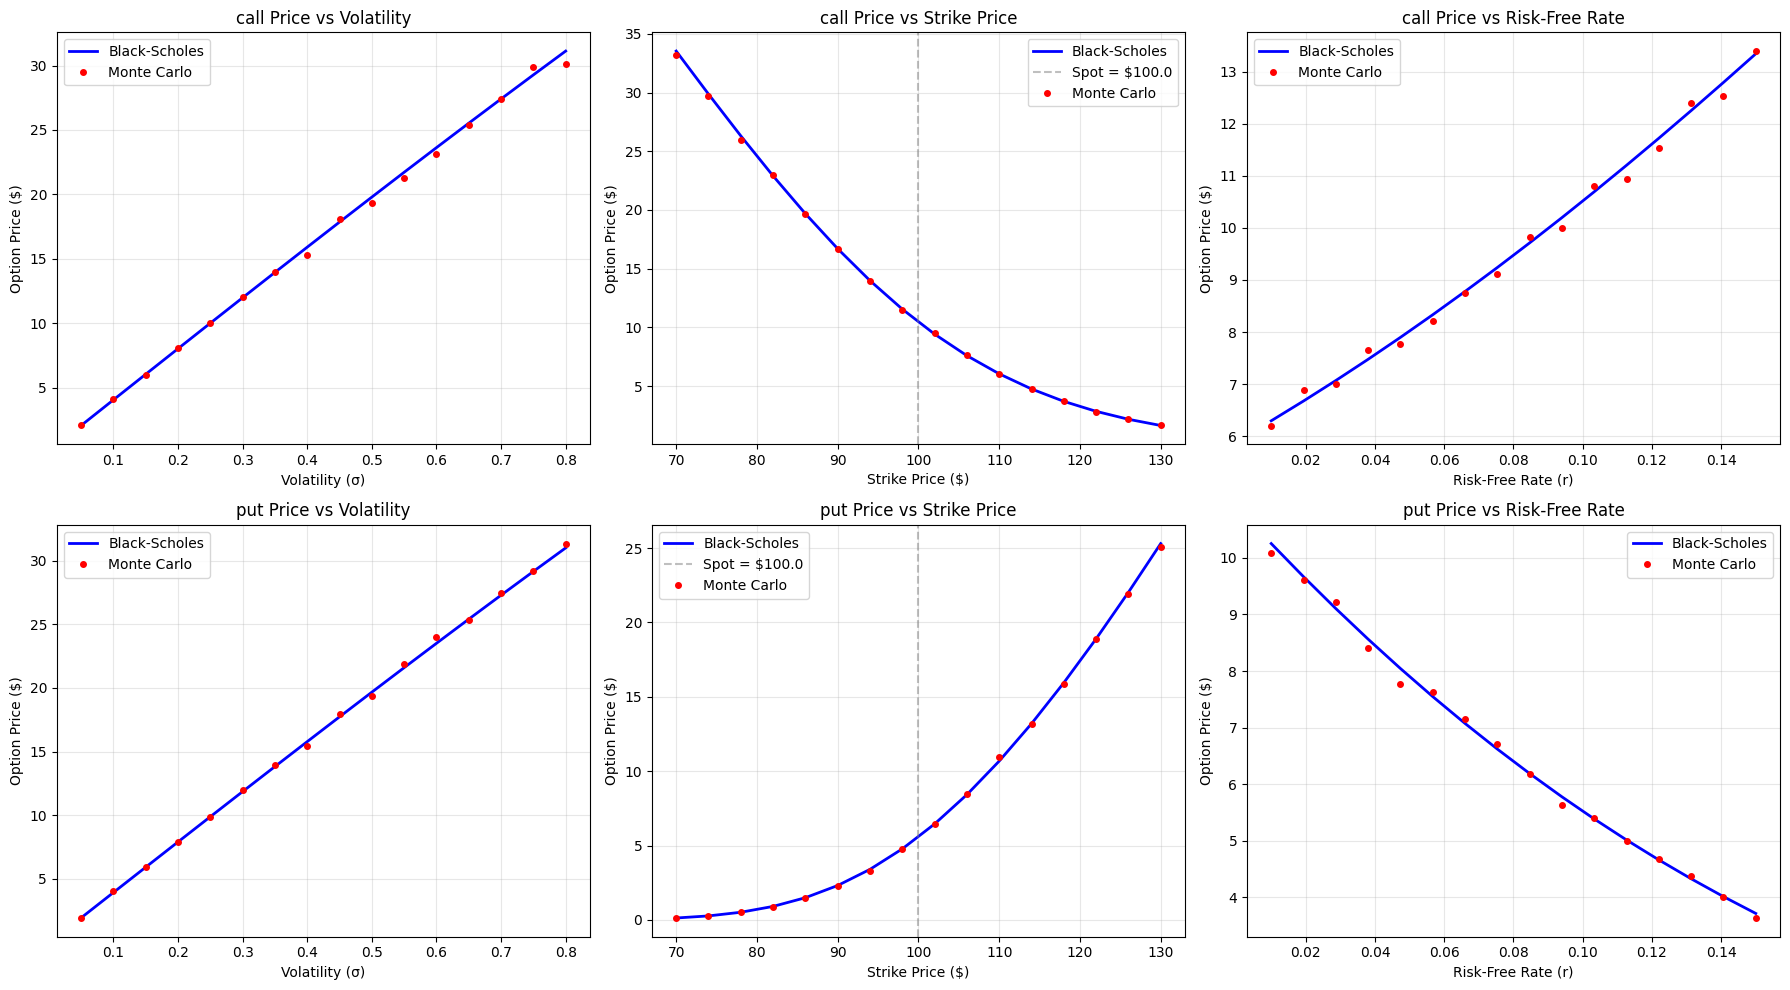

In [ ]:
def black_scholes(S, K, T, r, sigma, option_type):

    """
    Returns option price using black scholes model from given varirables-
    S - Stock price
    K - Strike price
    T - time to maturtity
    Sigma - Market volatility
    Option type - call or put
    """
    
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == "call":
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2) # call = S * N(d1) - K * e^(-rT) * N(d2)
    elif option_type == "put": 
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1) # put = K * e^(-rT) * N(-d2) - S * N(-d1)
    else:
        return 0
 
    return price


def derived_greeks(S, K, T, r, sigma, option_type):
    
    """
    greeks -
    
    - delta - option price change per 1 unit stock price change
        call - N(d1)
        put - N(d1) - 1
    
    - gamma - derivative(gradient) of delta
        call and put - n(d1) / (S * Sigma * √T)
    
    - theta - loss in option value due to time
        call - (-(S * N'(d1) * Sigma) / (2 * √T) - r * K * exp(-r * T) * N(d2)) / 365
        put - (-(S * N'(d1) * Sigma) / (2 * √T) + r * K * exp(-r * T) * N(d2)) / 365
    
    - vega - option price change per 1% of vol
        call and put - S * N'(d1) * √T
        
    - rho - option price change per 1% of intrest rate change
        call - K * T * e^(-rT) * N(d2)
        put - -K * T * e^(-rT) * N(d2)
    
    N'(x) - standard PDF at x """

    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":
        delta = norm.cdf(d1)
        theta = (-(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)) / 365
        rho = K * T * np.exp(-r * T) * norm.cdf(d2) / 100
        
    elif option_type == "put":
        delta = norm.cdf(d1) - 1
        theta = (-(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) + r * K * np.exp(-r * T) * norm.cdf(d2)) / 365
        rho = -K * T * np.exp(-r * T) * norm.cdf(d2) / 100

    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    vega = S * norm.pdf(d1) * np.sqrt(T) / 100

    derived_greeks = {
     "delta": delta,
     "gamma": gamma,
     "theta": theta,
     "vega": vega,
     "rho": rho
    }

    return derived_greeks
    
    

def simulate_gbm_paths(S0, r, sigma, T, n_steps, n_simulations):

    dt = T / n_steps # size of each step in time
    paths = np.zeros((n_simulations, n_steps + 1)) # matrix keeping stock prices at time T at collumn T for each path
    paths[:, 0] = S0  # sets all initial price of paths to stock price
    Z = np.random.standard_normal((n_simulations, n_steps)) # matrix of normal "shocks"

    # Geometric Brownian Motion formula
    
    for t in range(n_steps):
        paths[:, t + 1] = paths[:, t] * np.exp((r - (sigma ** 2) / 2) * dt # deterministic drift part
            + sigma * np.sqrt(dt) * Z[:, t]) # random diffusion part
        
    return paths




def monte_carlo_option_price(S0, K, T, r, sigma, option_type):
    
    n_simulations = 10000
    n_steps = 252 # daily
    
    paths = simulate_gbm_paths(S0, r, sigma, T, n_steps, n_simulations) # sims all paths
    final_prices = paths[:, -1] # list of final prices

    # payoff
    if option_type == "call":
        payoffs = np.maximum(final_prices - K, 0)
    else:
        payoffs = np.maximum(K - final_prices, 0)

    mc_price = np.exp(-r * T) * np.mean(payoffs) # discounts average payoff to present time

    return mc_price


def calculated_greeks(S0, K, T, r, sigma, option_type):
    """
    calculates greeks using "bump and revalue method", adjusts a small variable depeding on
    each greek e.g. the rate for rho and measures differnece divided by 2x the bump
    """
    
    n_simulations = 10000

    dS = S0 * 0.01 # 1% bump in stock price
    dT = 1 / 365   # 1 day bump in time
    dSigma = 0.01  # 1 percentage point in volatility
    dR = 0.001     # 0.1 percentage point bump in rate


    base_price = monte_carlo_option_price(
        S0, K, T, r, sigma, option_type)

    # delta
    price_up_S = monte_carlo_option_price(S0 + dS, K, T, r, sigma, option_type)
    price_dn_S = monte_carlo_option_price(S0 - dS, K, T, r, sigma, option_type)
    
    delta = (price_up_S - price_dn_S) / (2 * dS)


    # gamma
    # uses the three-point formula: [f(x+h) - 2f(x) + f(x-h)] / h^2
    gamma = (price_up_S - 2 * base_price + price_dn_S) / (dS ** 2)


    # theta
    price_less_time = monte_carlo_option_price(
        S0, K, T - dT, r, sigma, option_type)
    theta = (price_less_time - base_price) # day price change


    # vega
    price_up_vol = monte_carlo_option_price(
        S0, K, T, r, sigma + dSigma, option_type)
    price_dn_vol = monte_carlo_option_price(
        S0, K, T, r, sigma - dSigma, option_type)
    
    vega = (price_up_vol - price_dn_vol) / (2 * dSigma * 100)
    

    # rho
    price_up_r = monte_carlo_option_price(
        S0, K, T, r + dR, sigma, option_type)
    price_dn_r = monte_carlo_option_price(
        S0, K, T, r - dR, sigma, option_type)
    
    rho = (price_up_r - price_dn_r) / (2 * dR * 100)


    calculated_greeks = {
     "delta": delta,
     "gamma": gamma,
     "theta": theta,
     "vega": vega,
     "rho": rho
    }

    return calculated_greeks





# plotting greeks - 

def plot_greeks_vs_S(K, T, r, sigma):

    spot_range = np.linspace(K * 0.5, K * 1.5, 200) # generates 200 linear stock prices
    greek_names = ["delta", "gamma", "theta", "vega", "rho"]

    fig, axes = plt.subplots(1, 5, figsize=(18, 10))

    for i in range(len(greek_names)):
        call_vals = []
        put_vals = []

        for S in spot_range:
            call_g = calculated_greeks(S, K, T, r, sigma, "call")
            put_g = calculated_greeks(S, K, T, r, sigma, "put")
            call_vals.append(call_g[greek_names[i]])
            put_vals.append(put_g[greek_names[i]])

        ax = axes[i]
        ax.plot(spot_range, call_vals, "b-", linewidth=2, label="Call")
        ax.plot(spot_range, put_vals, "r--", linewidth=2, label="Put")
        ax.axvline(x=K, color="gray", linestyle=":", alpha=0.5,
                   label="Strike = $%s" % K)
        ax.set_xlabel("Stock Price ($)")
        ax.set_title(greek_names[i])
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    fig.suptitle("Option Greeks vs Stock Price  |  K=$%s, T=%sy, sigma=%s, r=%s" % 
                (K, T, "{:.0%}".format(sigma), "{:.0%}".format(r)),
                fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("greeks_vs_spot.png", dpi=150, bbox_inches="tight")


def plot_greeks_vs_T(K, T, r, sigma):

    time_range = np.linspace(0.01, 2.0, 200)
    greek_names = ["delta", "gamma", "theta", "vega", "rho"]

    fig, axes = plt.subplots(1, 5, figsize=(18, 10))

    for i in range(len(greek_names)):
        call_vals = []
        put_vals = []

        for T in time_range:
            call_g = analytical_greeks(S, K, T, r, sigma, "call")
            put_g = analytical_greeks(S, K, T, r, sigma, "put")
            call_vals.append(call_g[greek_names[i]])
            put_vals.append(put_g[greek_names[i]])

        ax = axes[i]
        ax.plot(time_range, call_vals, "b-", linewidth=2, label="Call")
        ax.plot(time_range, put_vals, "r--", linewidth=2, label="Put")
        ax.set_xlabel("Time to Expiry (years)")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig("greeks_vs_time.png", dpi=150, bbox_inches="tight")

    


# Sensitivity analysis - 

def sensitivity_analysis(S0, K, T, r, sigma):

    # run sensitivity analysis across volatility, strike price, and risk-free rate.
    n_sims = 10000

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    
    # vol sensitivity
    
    sigmas = np.linspace(0.05, 0.80, 16)

    for i, opt_type in enumerate(["call", "put"]):
        mc_prices = []
        bs_prices = []
    
    
        for s in sigmas:
            mc_p = monte_carlo_option_price(
                S0, K, T, r, s, opt_type)
            bs_p = black_scholes(S0, K, T, r, s, opt_type)
            
            mc_prices.append(mc_p)
            bs_prices.append(bs_p)

        
        ax = axes[i, 0]
        ax.plot(sigmas, bs_prices, "b-", linewidth=2, label="Black-Scholes")
        ax.errorbar(sigmas, mc_prices, fmt="ro", markersize=4,
                    capsize=3, label="Monte Carlo")
        ax.set_xlabel("Volatility (σ)")
        ax.set_ylabel("Option Price ($)")
        ax.set_title("%s Price vs Volatility" % opt_type)
        ax.legend()
        ax.grid(True, alpha=0.3)


    
    # strike sensitivity
    
    strikes = np.linspace(S0 * 0.7, S0 * 1.3, 16)

    for i, opt_type in enumerate(["call", "put"]):
        mc_prices = []
        bs_prices = []
        
        for k in strikes:
            mc_p = monte_carlo_option_price(
                S0, k, T, r, sigma, opt_type)
            bs_p = black_scholes(S0, k, T, r, sigma, opt_type)
            
            mc_prices.append(mc_p)
            bs_prices.append(bs_p)
            


        
        ax = axes[i, 1]
        ax.plot(strikes, bs_prices, "b-", linewidth=2, label="Black-Scholes")
        ax.errorbar(strikes, mc_prices, fmt="ro", markersize=4,
                    capsize=3, label="Monte Carlo")
        ax.axvline(x=S0, color="gray", linestyle="--", alpha=0.5,
                   label="Spot = $%s" % S0)
        ax.set_xlabel("Strike Price ($)")
        ax.set_ylabel("Option Price ($)")
        ax.set_title("%s Price vs Strike Price" % opt_type)
        ax.legend()
        ax.grid(True, alpha=0.3)


    # rates sensitivity

    rates = np.linspace(0.01, 0.15, 16)

    for i, opt_type in enumerate(["call", "put"]):
        mc_prices = []
        bs_prices = []

        for rate in rates:
            mc_p = monte_carlo_option_price(
                S0, K, T, rate, sigma, opt_type)
            bs_p = black_scholes(S0, K, T, rate, sigma, opt_type)
            mc_prices.append(mc_p)
            bs_prices.append(bs_p)


        ax = axes[i, 2]
        ax.plot(rates, bs_prices, "b-", linewidth=2, label="Black-Scholes")
        ax.errorbar(rates, mc_prices, fmt="ro", markersize=4,
                    capsize=3, label="Monte Carlo")
        ax.set_xlabel("Risk-Free Rate (r)")
        ax.set_ylabel("Option Price ($)")
        ax.set_title("%s Price vs Risk-Free Rate" % opt_type)
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("sensitivity_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()


def plot_sim_paths(S0, r, sigma, T):

    n_steps = 252 # provides daily changes
    n_simulations = 10000

    paths = simulate_gbm_paths(S0, r, sigma, T, n_steps, n_simulations)
    time_grid = np.linspace(0, T, n_steps + 1)

    fig, ax = plt.subplots(figsize=(16, 6))

    for i in range(100): #only displaying 100
        ax.plot(time_grid, paths[i, :], alpha=0.3, linewidth=0.5)
        
    mean_path = np.mean(paths, axis=0)
    ax.plot(time_grid, mean_path, "k-", linewidth=2, label="Mean Path")
    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Stock Price ($)")
    ax.set_title("Simulated GBM Paths (%s of %s)" % (100, n_simulations))
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.savefig("simulated_paths.png", dpi=150, bbox_inches="tight")
    plt.show()


def main():

    # test parameters
    
    S0    = 100.0    
    K     = 105.0    
    T     = 1.0     
    r     = 0.05     
    sigma = 0.20     
    N_SIM = 100000 

    print("\nMONTE CARLO OPTION PRICER WITH GREEKS\n")

    mc_call = monte_carlo_option_price(
        S0, K, T, r, sigma, "call")
    bs_call = black_scholes(S0, K, T, r, sigma, "call")

    mc_put = monte_carlo_option_price(
        S0, K, T, r, sigma, "put")
    bs_put = black_scholes(S0, K, T, r, sigma, "put")

    print("\n  CALL OPTION:")
    print("    Monte Carlo Price  : $%s" % round(mc_call, 2))
    print("    Black-Scholes Price: $%s" % round(bs_call, 2))
    print("    Pricing Error      : %s%%" % round((abs(mc_call - bs_call) / bs_call * 100), 2))
    
    print("\n  PUT OPTION:")
    print("    Monte Carlo Price  : $%s" % round(mc_put, 2))
    print("    Black-Scholes Price: $%s" % round(bs_put, 2))
    print("    Pricing Error      : %s%%" % round((abs(mc_put - bs_put) / bs_put * 100), 2))
    
    print("\n\nOPTION GREEKS")
    
    for option in ["call", "put"]:
        print("\n%s GREEKS:" % option.upper())
        print("Name:  BS:  MC:  Diff:")
        d_greeks = derived_greeks(S0, K, T, r, sigma, option)
        c_greeks = calculated_greeks(S0, K, T, r, sigma, option)
        for name in ["delta ", "gamma ", "theta", "vega  ", "rho   "]:
            d_val = d_greeks[name.strip()]
            c_val = c_greeks[name.strip()]
            diff = abs(d_val - c_val)
            print(name, round(d_val, 2), round(c_val, 2), round(diff, 2))

    
    # creating graphs
    plot_sim_paths(S0, r, sigma, T)
    sensitivity_analysis(S0, K, T, r, sigma)
    plot_greeks_vs_S(K, T, r, sigma)
    print("\nGreeks vs Spot saved.\n")
    plot_greeks_vs_T(S0, K, r, sigma)
    print("\nGreeks vs Time saved.\n")


    

    
    
main()
        
